# V1 Orientation Sequence Simulation and Raster

This notebook runs `SystemNESTSim` with 8 visual orientations.

Stimulus protocol:
- 8 orientations: 0°, 45°, 90°, 135°, 180°, 225°, 270°, 315°
- each orientation shown for 1 second
- 1 second blank gap between orientations

Then it plots a population activity raster across neurons.

In [5]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np

from run_system_nest_sim import SystemNESTSim

In [6]:
# Simple orientation sequence: alternate orientation vector and zero vector
orientations_deg = [0, 45, 90, 135, 180, 225, 270, 315]
dt_ms = 1000.0

orientation_vectors = []
epoch_info = []  # (start_ms, end_ms, label) for plotting
cursor_ms = 0.0

for theta_deg in orientations_deg:
    theta = np.deg2rad(theta_deg)
    vec = [np.cos(theta), np.sin(theta)]

    # 1 second orientation input
    orientation_vectors.append(vec)
    epoch_info.append((cursor_ms, cursor_ms + dt_ms, f"{theta_deg}°"))
    cursor_ms += dt_ms

    # 1 second blank input
    orientation_vectors.append([0.0, 0.0])
    cursor_ms += dt_ms

orientation_time_series = np.asarray(orientation_vectors, dtype=float)
input_duration_ms = len(orientation_time_series) * dt_ms

print("orientation_time_series shape:", orientation_time_series.shape)
print("input_duration_ms:", input_duration_ms)

orientation_time_series shape: (16, 2)
input_duration_ms: 16000.0


In [ ]:
# Run simulation
sim = SystemNESTSim(output_name="visual_orientations_8")
result_paths = sim.visual_stim(
    orientation_time_series=orientation_time_series,
    input_duration_ms=input_duration_ms,
    dt_ms=dt_ms,
    baseline_pA=0.0,
    gain_pA=80.0,
    sparsity=0.01,
    seed=7,
    output_prefix="visual8",
)

print("Simulation complete.")
print("Data path:", sim.sim_dict["data_path"])
print(result_paths)

Data will be written to: /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/visual_orientations_8
  Directory already existed. Old data will be overwritten.

Neuron numbers are scaled by a factor of 0.050.
Indegrees are scaled by a factor of 0.050.
  Weights and DC input are adjusted to compensate.

RNG seed: 42
Total number of virtual processes: 4
Creating neuronal populations.
Creating recording devices.
  Creating spike recorders.
Creating Poisson generators for background input.
Connecting neuronal populations recurrently.
Connecting Poisson generators for background input.
Simulating 1000 ms.
SystemNESTSim initialized.
Total # neurons simulated: 3858
Data path: /Users/bhaishahster/GITs/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/visual_orientations_8


In [8]:
def load_spikes_robust(path, name_prefix, begin_ms, end_ms):
    spike_files = sorted(glob.glob(os.path.join(path, f"{name_prefix}-*.dat")))
    if len(spike_files) == 0:
        raise FileNotFoundError(f"No files found for prefix '{name_prefix}' in {path}")

    node_ids = np.loadtxt(os.path.join(path, "population_nodeids.dat"), dtype=int)
    if node_ids.ndim == 1:
        node_ids = node_ids[None, :]

    last_node_id = node_ids[-1, -1]
    all_times = []
    all_neurons = []

    for file_path in spike_files:
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                parts = stripped.split()
                if len(parts) < 2:
                    continue
                try:
                    sender = int(float(parts[0]))
                    time_ms = float(parts[1])
                except ValueError:
                    continue

                if begin_ms <= time_ms <= end_ms:
                    neuron_idx = abs(sender - last_node_id) + 1
                    all_times.append(time_ms)
                    all_neurons.append(neuron_idx)

    return np.asarray(all_times), np.asarray(all_neurons), spike_files

raster_begin_ms = 0
raster_end_ms = input_duration_ms
times_all, neurons_all, spike_files = load_spikes_robust(
    sim.sim_dict["data_path"], "spike_recorder", raster_begin_ms, raster_end_ms
)

print(f"Loaded {len(times_all)} spikes from {len(spike_files)} files.")

Loaded 8113 spikes from 32 files.


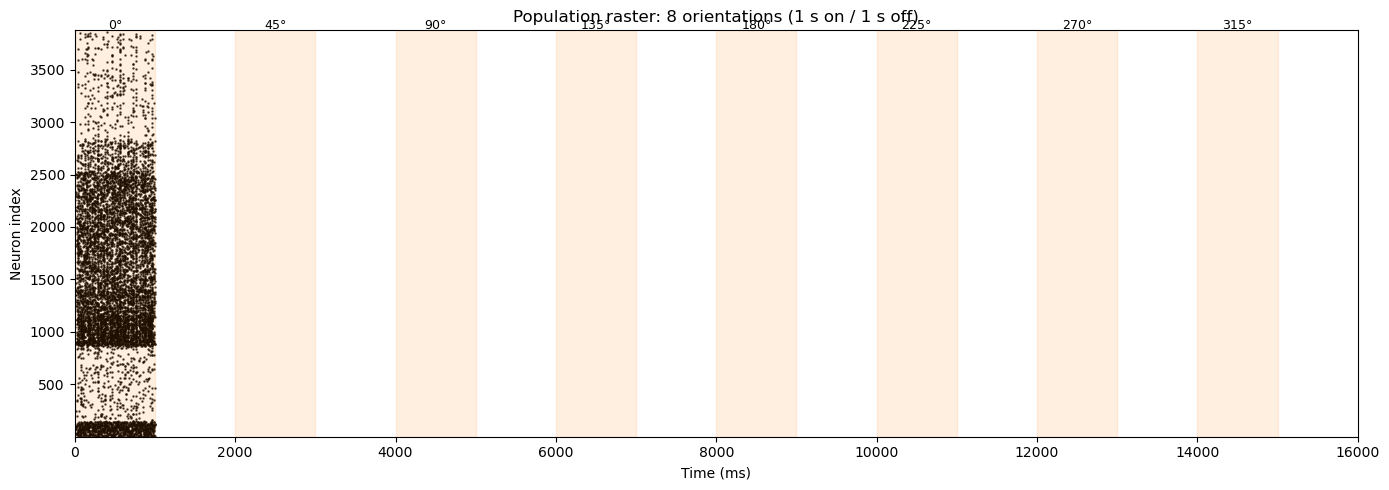

In [9]:
if len(times_all) == 0:
    print("No spikes found in selected range.")
else:
    plt.figure(figsize=(14, 5))
    plt.scatter(times_all, neurons_all, s=0.6, c="k", alpha=0.7)

    ymin, ymax = np.min(neurons_all), np.max(neurons_all)
    for start_ms, end_ms, label in epoch_info:
        plt.axvspan(start_ms, end_ms, color="tab:orange", alpha=0.12)
        plt.text(
            0.5 * (start_ms + end_ms),
            ymax + 5,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.xlim(raster_begin_ms, raster_end_ms)
    plt.ylim(ymin, ymax + 20)
    plt.xlabel("Time (ms)")
    plt.ylabel("Neuron index")
    plt.title("Population raster: 8 orientations (1 s on / 1 s off)")
    plt.tight_layout()
    plt.show()